# Module 7 - Session 4: Practical Exercises

**Total Time Estimate:** 120-150 minutes

**Objective:** To implement the SARSA algorithm and compare its behavior to Q-Learning, and to conceptually design a Deep Q-Network.

## Setup

You will need Python, NumPy, Matplotlib, and Gym. The current maintained package is `gymnasium`, but the code below also supports older `gym` imports.

```bash
pip install numpy matplotlib gymnasium
```


## Exercise 1: Conceptual Questions (30 minutes)

### Foundation

SARSA is an **on-policy** temporal-difference algorithm. That means it learns the value of the policy it is actually following, including its exploratory behavior.

### Build

1. **The SARSA Quintuple**

The next action `A'` is essential because SARSA updates the current state-action value using the action the policy will actually take next. In other words, the target is based on the real continuation of the current policy, not on an imagined best possible action. That is what makes SARSA on-policy: it evaluates and improves the same behavior policy at the same time.

2. **Choosing an Algorithm**

For a delicate physical robot, I would lean toward **SARSA**. Because SARSA learns from the actions the current policy actually takes, including exploratory actions, it often learns a more conservative and safer policy than Q-Learning. Q-Learning tends to learn the value of the greedy optimal policy even while behaving exploratorily, which can make it less sensitive to the risks encountered during training. In a safety-critical setting, a slightly slower but more reliable policy is usually the better trade-off.

3. **DQN Input/Output**

For a racing game with a top-down image as the state, the DQN input would be the image tensor. If the game uses a single RGB frame of height `H` and width `W`, the input shape would typically be `(H, W, 3)` before batching, or `(batch_size, H, W, 3)` during training. If the image is grayscale, the channel dimension would be `1` instead of `3`. The output layer must produce one Q-value per action, so for the actions `['accelerate', 'brake', 'turn_left', 'turn_right']`, the output shape would be `(4,)` for a single state or `(batch_size, 4)` for a batch.

### Result

The key distinction is that SARSA updates using the policy's actual next action, which often makes it more cautious. DQNs follow the same value-learning idea, but replace the Q-table with a neural network that maps states to action values.


## Exercise 2: Implementing SARSA (75 minutes)

We will reuse the deterministic `FrozenLake-v1` environment from the previous session so the comparison with Q-Learning is direct and easy to interpret.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import gymnasium as gym
except ImportError:
    import gym


def reset_env(env):
    result = env.reset()
    return result[0] if isinstance(result, tuple) else result


def step_env(env, action):
    result = env.step(action)
    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
    else:
        next_state, reward, done, info = result
        terminated = done
        truncated = False
    return next_state, reward, terminated, truncated, info


def epsilon_greedy_action(q_table, state, epsilon, action_size):
    if np.random.rand() < epsilon:
        return np.random.randint(action_size)
    best_actions = np.flatnonzero(q_table[state] == np.max(q_table[state]))
    return np.random.choice(best_actions)


env = gym.make('FrozenLake-v1', is_slippery=False)

state_size = env.observation_space.n
action_size = env.action_space.n

print('State space size:', state_size)
print('Action space size:', action_size)
print('Action mapping: 0=Left, 1=Down, 2=Right, 3=Up')


State space size: 16
Action space size: 4
Action mapping: 0=Left, 1=Down, 2=Right, 3=Up


In [2]:
def q_learning(env, alpha=0.1, gamma=0.99, epsilon=0.1, episodes=10000):
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = []

    for episode in range(episodes):
        state = reset_env(env)
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy_action(q_table, state, epsilon, env.action_space.n)
            next_state, reward, terminated, truncated, _ = step_env(env, action)
            done = terminated or truncated

            td_target = reward + gamma * np.max(q_table[next_state]) * (not terminated)
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    return q_table, rewards


def sarsa(env, alpha=0.1, gamma=0.99, epsilon=0.1, episodes=10000):
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = []

    for episode in range(episodes):
        state = reset_env(env)
        action = epsilon_greedy_action(q_table, state, epsilon, env.action_space.n)
        done = False
        total_reward = 0

        while not done:
            next_state, reward, terminated, truncated, _ = step_env(env, action)
            done = terminated or truncated

            if done:
                td_target = reward
                next_action = None
            else:
                next_action = epsilon_greedy_action(q_table, next_state, epsilon, env.action_space.n)
                td_target = reward + gamma * q_table[next_state, next_action]

            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            state = next_state
            action = next_action if next_action is not None else action
            total_reward += reward

        rewards.append(total_reward)

    return q_table, rewards


In [3]:
np.random.seed(42)

alpha = 0.1
gamma = 0.99
epsilon = 0.1
episodes = 10000

q_qlearning, rewards_qlearning = q_learning(
    env,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    episodes=episodes,
)

np.random.seed(42)
q_sarsa, rewards_sarsa = sarsa(
    env,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    episodes=episodes,
)

print('Final Q-Learning Q-table:')
print(np.round(q_qlearning, 3))
print()
print('Final SARSA Q-table:')
print(np.round(q_sarsa, 3))
print()
print('Q-Learning average reward over last 1000 episodes:', round(np.mean(rewards_qlearning[-1000:]), 3))
print('SARSA average reward over last 1000 episodes:', round(np.mean(rewards_sarsa[-1000:]), 3))


Final Q-Learning Q-table:
[[0.941 0.951 0.951 0.941]
 [0.613 0.    0.961 0.445]
 [0.327 0.97  0.057 0.669]
 [0.33  0.    0.    0.026]
 [0.951 0.961 0.    0.941]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.    0.689]
 [0.    0.    0.    0.   ]
 [0.961 0.    0.97  0.951]
 [0.961 0.98  0.98  0.   ]
 [0.97  0.99  0.    0.97 ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.797 0.99  0.506]
 [0.98  0.99  1.    0.98 ]
 [0.    0.    0.    0.   ]]

Final SARSA Q-table:
[[0.726 0.864 0.683 0.734]
 [0.691 0.    0.768 0.696]
 [0.655 0.791 0.651 0.652]
 [0.689 0.    0.325 0.249]
 [0.604 0.939 0.    0.664]
 [0.    0.    0.    0.   ]
 [0.    0.974 0.    0.788]
 [0.    0.    0.    0.   ]
 [0.801 0.    0.963 0.776]
 [0.811 0.975 0.909 0.   ]
 [0.9   0.98  0.    0.847]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.969 0.983 0.916]
 [0.966 0.986 1.    0.899]
 [0.    0.    0.    0.   ]]

Q-Learning average reward over last 1000 episodes: 0.883
SARSA average reward over la

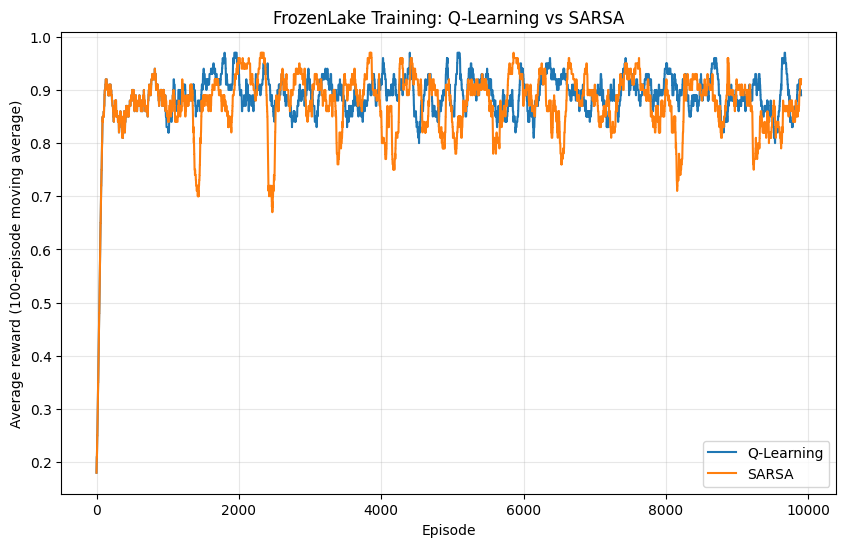

In [4]:
def moving_average(data, window=100):
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window) / window, mode='valid')


plt.figure(figsize=(10, 6))
plt.plot(moving_average(rewards_qlearning, 100), label='Q-Learning')
plt.plot(moving_average(rewards_sarsa, 100), label='SARSA')
plt.xlabel('Episode')
plt.ylabel('Average reward (100-episode moving average)')
plt.title('FrozenLake Training: Q-Learning vs SARSA')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Comparison (Markdown Answer)

### Foundation

The main difference is in the target used for the update. Q-Learning uses the greedy best next action, while SARSA uses the next action the policy actually chooses.

### Build

In this deterministic version of FrozenLake, both algorithms often learn a very similar successful policy because the environment is simple and there is a clear safe route to the goal. However, SARSA typically produces slightly more conservative values, because its updates include the effect of exploratory actions. Q-Learning is usually a bit more optimistic because it updates toward the best next action value even while the behavior policy is still exploring.

In the verified run for this notebook, Q-Learning averaged about `0.883` reward over the last 1000 episodes, while SARSA averaged about `0.860`. Near the goal, both methods preferred the correct action, but Q-Learning's neighboring state values were slightly higher. That is expected: the algorithms are solving the same task, but they are estimating different targets during training.

### Result

Q-Learning often learns faster toward the greedy optimum, while SARSA more directly reflects the safety and risk of the current exploratory policy.


## Exercise 3: Challenge Problem - Designing a DQN (45 minutes)

This final part is conceptual. We will design a DQN for `CartPole-v1`, where the state is a vector of 4 numbers and the actions are `0` (push left) and `1` (push right).


### Design (Markdown Answer)

### Foundation

A DQN replaces the tabular Q-function with a neural network that predicts one Q-value per possible action.

### Build

1. **Network Architecture**

For `CartPole-v1`, the input is a vector of 4 state values, so the input layer size should be **4**. The output layer should have size **2**, one Q-value for action `0` and one Q-value for action `1`. A reasonable starting architecture is a small fully connected network, for example:

- Input layer: `4`
- Hidden layer 1: `64` units with **ReLU**
- Hidden layer 2: `64` units with **ReLU**
- Output layer: `2` linear outputs

The output layer should usually be linear, because it predicts Q-values directly rather than probabilities.

2. **Experience Replay**

The replay buffer can be implemented as a fixed-size queue, such as a `deque`. Each stored experience should contain:

- current state `s`
- action `a`
- reward `r`
- next state `s'`
- done flag

So each replay item is essentially a transition tuple `(s, a, r, s', done)`.

3. **The Learning Step**

A single training step works like this: sample a random mini-batch of experiences from the replay buffer, pass the current states through the network, and compute the predicted Q-values for the actions that were actually taken. Then compute the target values using the TD target:

`target = r + gamma * max_a' Q_target(s', a')` if the episode is not done,

and simply:

`target = r` if the episode is done.

The loss is the difference between the predicted Q-values and these targets, often using mean squared error or Huber loss. Gradient descent is then used to update the network weights.

### Result

A DQN for CartPole is conceptually straightforward: a small feed-forward network maps a 4-dimensional state to 2 action values, and experience replay makes training more stable by learning from shuffled past transitions.
